In [1]:
import pandas as pd

from benchmarking.metrics.base_metrics import load_all_feature_tables
import matplotlib.pyplot as plt

from matplotlib_venn import venn2

# Load in data

In [2]:
# Building the feature table for reframe_spikein_dataset
merged_feature_tables = load_all_feature_tables(
    ["../data/groundtruth_dataset/plant_spikein"],
    annotation_subfolder="annotated_spectral_entropy",
)

100%|██████████| 1/1 [00:03<00:00,  3.10s/it]


# Compounds overlapping acorss tools

In [5]:
from collections import defaultdict

concentration_cmpds = defaultdict(set)

for tool, tool_df in merged_feature_tables.items():
    column_names = [col for col in tool_df.columns if "SAMPLE" in col]
    for _, column in enumerate(column_names):
        compound_name = column.split("_")[1]
        conc = int(column.split("_")[2].replace("ng", "").strip())
        concentration_cmpds[conc].add(compound_name)

In [6]:
concentration_cmpds.keys()

dict_keys([50, 100, 200])

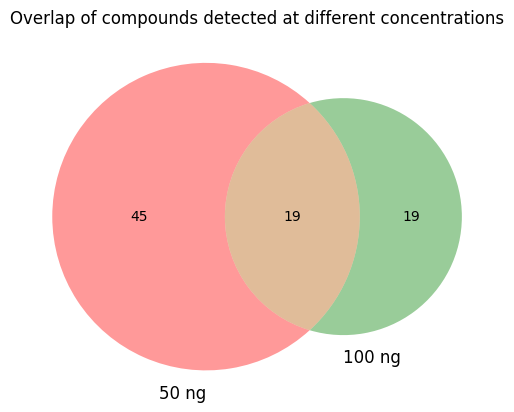

In [11]:
venn2(
    subsets=(
        len(concentration_cmpds[50]),
        len(concentration_cmpds[100]),
        len(concentration_cmpds[200]),
    ),
    set_labels=("50 ng", "100 ng"),
)
plt.title("Overlap of compounds detected at different concentrations")
plt.show()

In [12]:
overlapping_cmpds = (
    concentration_cmpds[50]
    .intersection(concentration_cmpds[100])
    .intersection(concentration_cmpds[200])
)
print(f"Compounds detected at all concentrations: {overlapping_cmpds}")

Compounds detected at all concentrations: {'maltol', 'lupinine', 'coumarin', 'hydroxy-alpha-sanshool', 'catharanthine', 'cryptotanshinone', 'hordenine', 'indole-3-carbinol', 'hederagenin', 'plumbagin', 'lotusine', 'oxindole', 'protocatechualdehyde', 'psoralen', 'tropinone', 'synephrine', 'cannabidivarin'}
